In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("housing.csv") 
    

In [8]:
df['income_cat']  = pd.cut(df['median_income'],bins =[0,1.5, 3.0, 4.5, 6.0, np.inf], labels=[1,2,3,4,5]) 

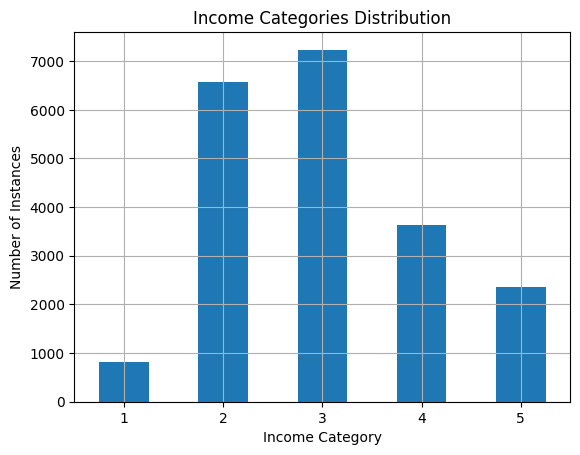

In [9]:
import matplotlib.pyplot as plt
df["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)  
plt.title("Income Categories Distribution") 
plt.xlabel("Income Category")
plt.ylabel("Number of Instances")
plt.show()

In [10]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


In [11]:
def shuffle_and_split(data, test_ratio):
    np.random.seed(42) #set seeed for reproducibility [same set of random numbers at every function run-] >>>> option 1
    shuffled_indices= np.random.permutation(len(data)) #retuns the shuffled incides datasize >>>> option2
    test_set_size =  int(len(data) *test_ratio)
    test_indices= shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [12]:
train , test = shuffle_and_split(df, 0.3)

In [13]:
train.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
7061,-118.02,33.93,35.0,2400.0,398.0,1218.0,408.0,4.1312,193800.0,<1H OCEAN,3
14689,-117.09,32.79,20.0,2183.0,534.0,999.0,496.0,2.8631,169700.0,NEAR OCEAN,2
17323,-120.14,34.59,24.0,1601.0,282.0,731.0,285.0,4.2026,259800.0,NEAR OCEAN,3
10056,-121.00,39.26,14.0,810.0,151.0,302.0,138.0,3.1094,136100.0,INLAND,3
15750,-122.45,37.77,52.0,3188.0,708.0,1526.0,664.0,3.3068,500001.0,NEAR BAY,3


In [14]:
from sklearn.model_selection import StratifiedShuffleSplit

In [17]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [18]:
for train_idx, test_idx in split.split(df, df['income_cat']):
    strat_train_set= df.loc[train_idx]
    strat_test_set= df.loc[test_idx]


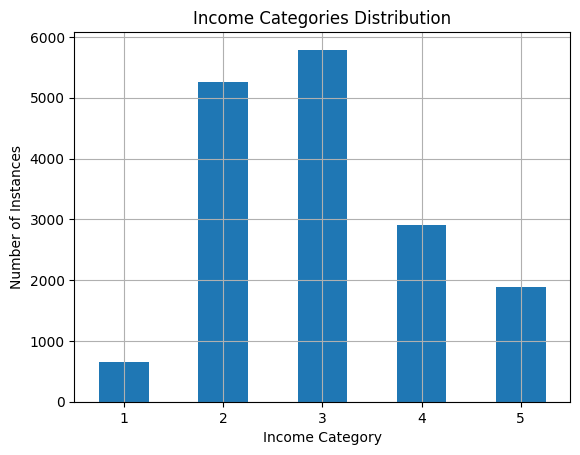

In [20]:
strat_train_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)  
plt.title("Income Categories Distribution") 
plt.xlabel("Income Category")
plt.ylabel("Number of Instances")
plt.show()